Referências:

https://www.kaggle.com/code/abdallahwagih/effecientnetb3-tomato-disease-detection-99-81/notebook

https://www.kaggle.com/code/astukari/tomato-leaf-disease-detection-w-yolov8/notebook

In [6]:
# Bloco 1 – Instalação da biblioteca (se necessário)

!pip install ultralytics

In [7]:
#  Bloco 2 – Importações

from ultralytics import YOLO
import os

In [9]:
# Bloco 3 – Carregar o modelo base

model = YOLO('yolov8n-cls.pt')

In [8]:
# Bloco 4 – Montar o Google Drive (se o dataset estiver lá)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Bloco 5 – Definir o caminho do dataset

# Exemplo com dataset dentro do próprio ambiente do Colab
dataset_path = '/content/drive/MyDrive/Doutorado_PGCOMP/Disciplinas/Inteligência Artificial/Workshop II/App/dataset'

# Se estiver no Drive:
# dataset_path = '/content/drive/MyDrive/seu_dataset'

In [ ]:
# Bloco 6 – Treinar o modelo

results = model.train(
    data=dataset_path,
    epochs=50,
    imgsz=224,
    project='meus_treinos',
    name='modelo_tomate_v1',
    save=True,
    save_period=1,  # salva um checkpoint a cada época (1 = todas as épocas)
    device=0,       # força o uso da GPU
    resume=False    # quando iniciar pela primeira vez, deixe False
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Doutorado_PGCOMP/Disciplinas/Inteligência Artificial/Workshop II/App/dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=modelo_tomate_v1, nbs=64, nms=

In [ ]:
# Bloco 7 – Exibir local do modelo salvo

print(f"O modelo foi guardado em: {os.path.join('meus_treinos', 'modelo_tomate_v1', 'weights', 'tomate.pt')}")

O modelo foi guardado em: meus_treinos/modelo_tomate_v1/weights/best.pt


In [ ]:
# Bloco 8 – Exportar para ONNX (opcional)

model_treinado = YOLO('/content/runs/classify/meus_treinos/modelo_tomate_v1/weights/tomate.pt')
model_treinado.export(format='onnx')

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
YOLOv8n-cls summary (fused): 30 layers, 1,448,971 parameters, 0 gradients, 3.3 GFLOPs

PyTorch: starting from '/content/runs/classify/meus_treinos/modelo_tomate_v1/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 11) (2.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 438ms
Prepared 4 packages in 2.40s
Installed 4 packages in 742ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 4.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 5.8s, saved as '/content/runs/classify/meus_treinos/modelo_tomate_v1/weights/best.onnx

'/content/runs/classify/meus_treinos/modelo_tomate_v1/weights/best.onnx'

In [ ]:
# Bloco 9 – Download dos resultados (opcional)

from google.colab import files
files.download('/content/runs/classify/meus_treinos/modelo_tomate_v1/weights/tomate.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,448,971 parameters, 0 gradients, 3.3 GFLOPs
train: /content/drive/MyDrive/Doutorado_PGCOMP/Disciplinas/Inteligência Artificial/Workshop II/App/dataset/train... found 5500 images in 11 classes ✅ 
val: /content/drive/MyDrive/Doutorado_PGCOMP/Disciplinas/Inteligência Artificial/Workshop II/App/dataset/val... found 5143 images in 11 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 0.6±0.3 MB/s, size: 311.8 KB)
val: Scanning /content/drive/MyDrive/Doutorado_PGCOMP/Disciplinas/Inteligência Artificial/Workshop II/App/dataset/val... 5143 images, 0 corrupt: 100% ━━━━━━━━━━━━ 5143/5143 653.7Mit/s 0.0s
val: /content/drive/MyDrive/Doutorado_PGCOMP/Disciplinas/Inteligência Artificial/Workshop II/App/dataset/val/Leaf_Mold/img (15).jpg: corrupt JPEG restored and saved
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 322/322 3.3s/it 1

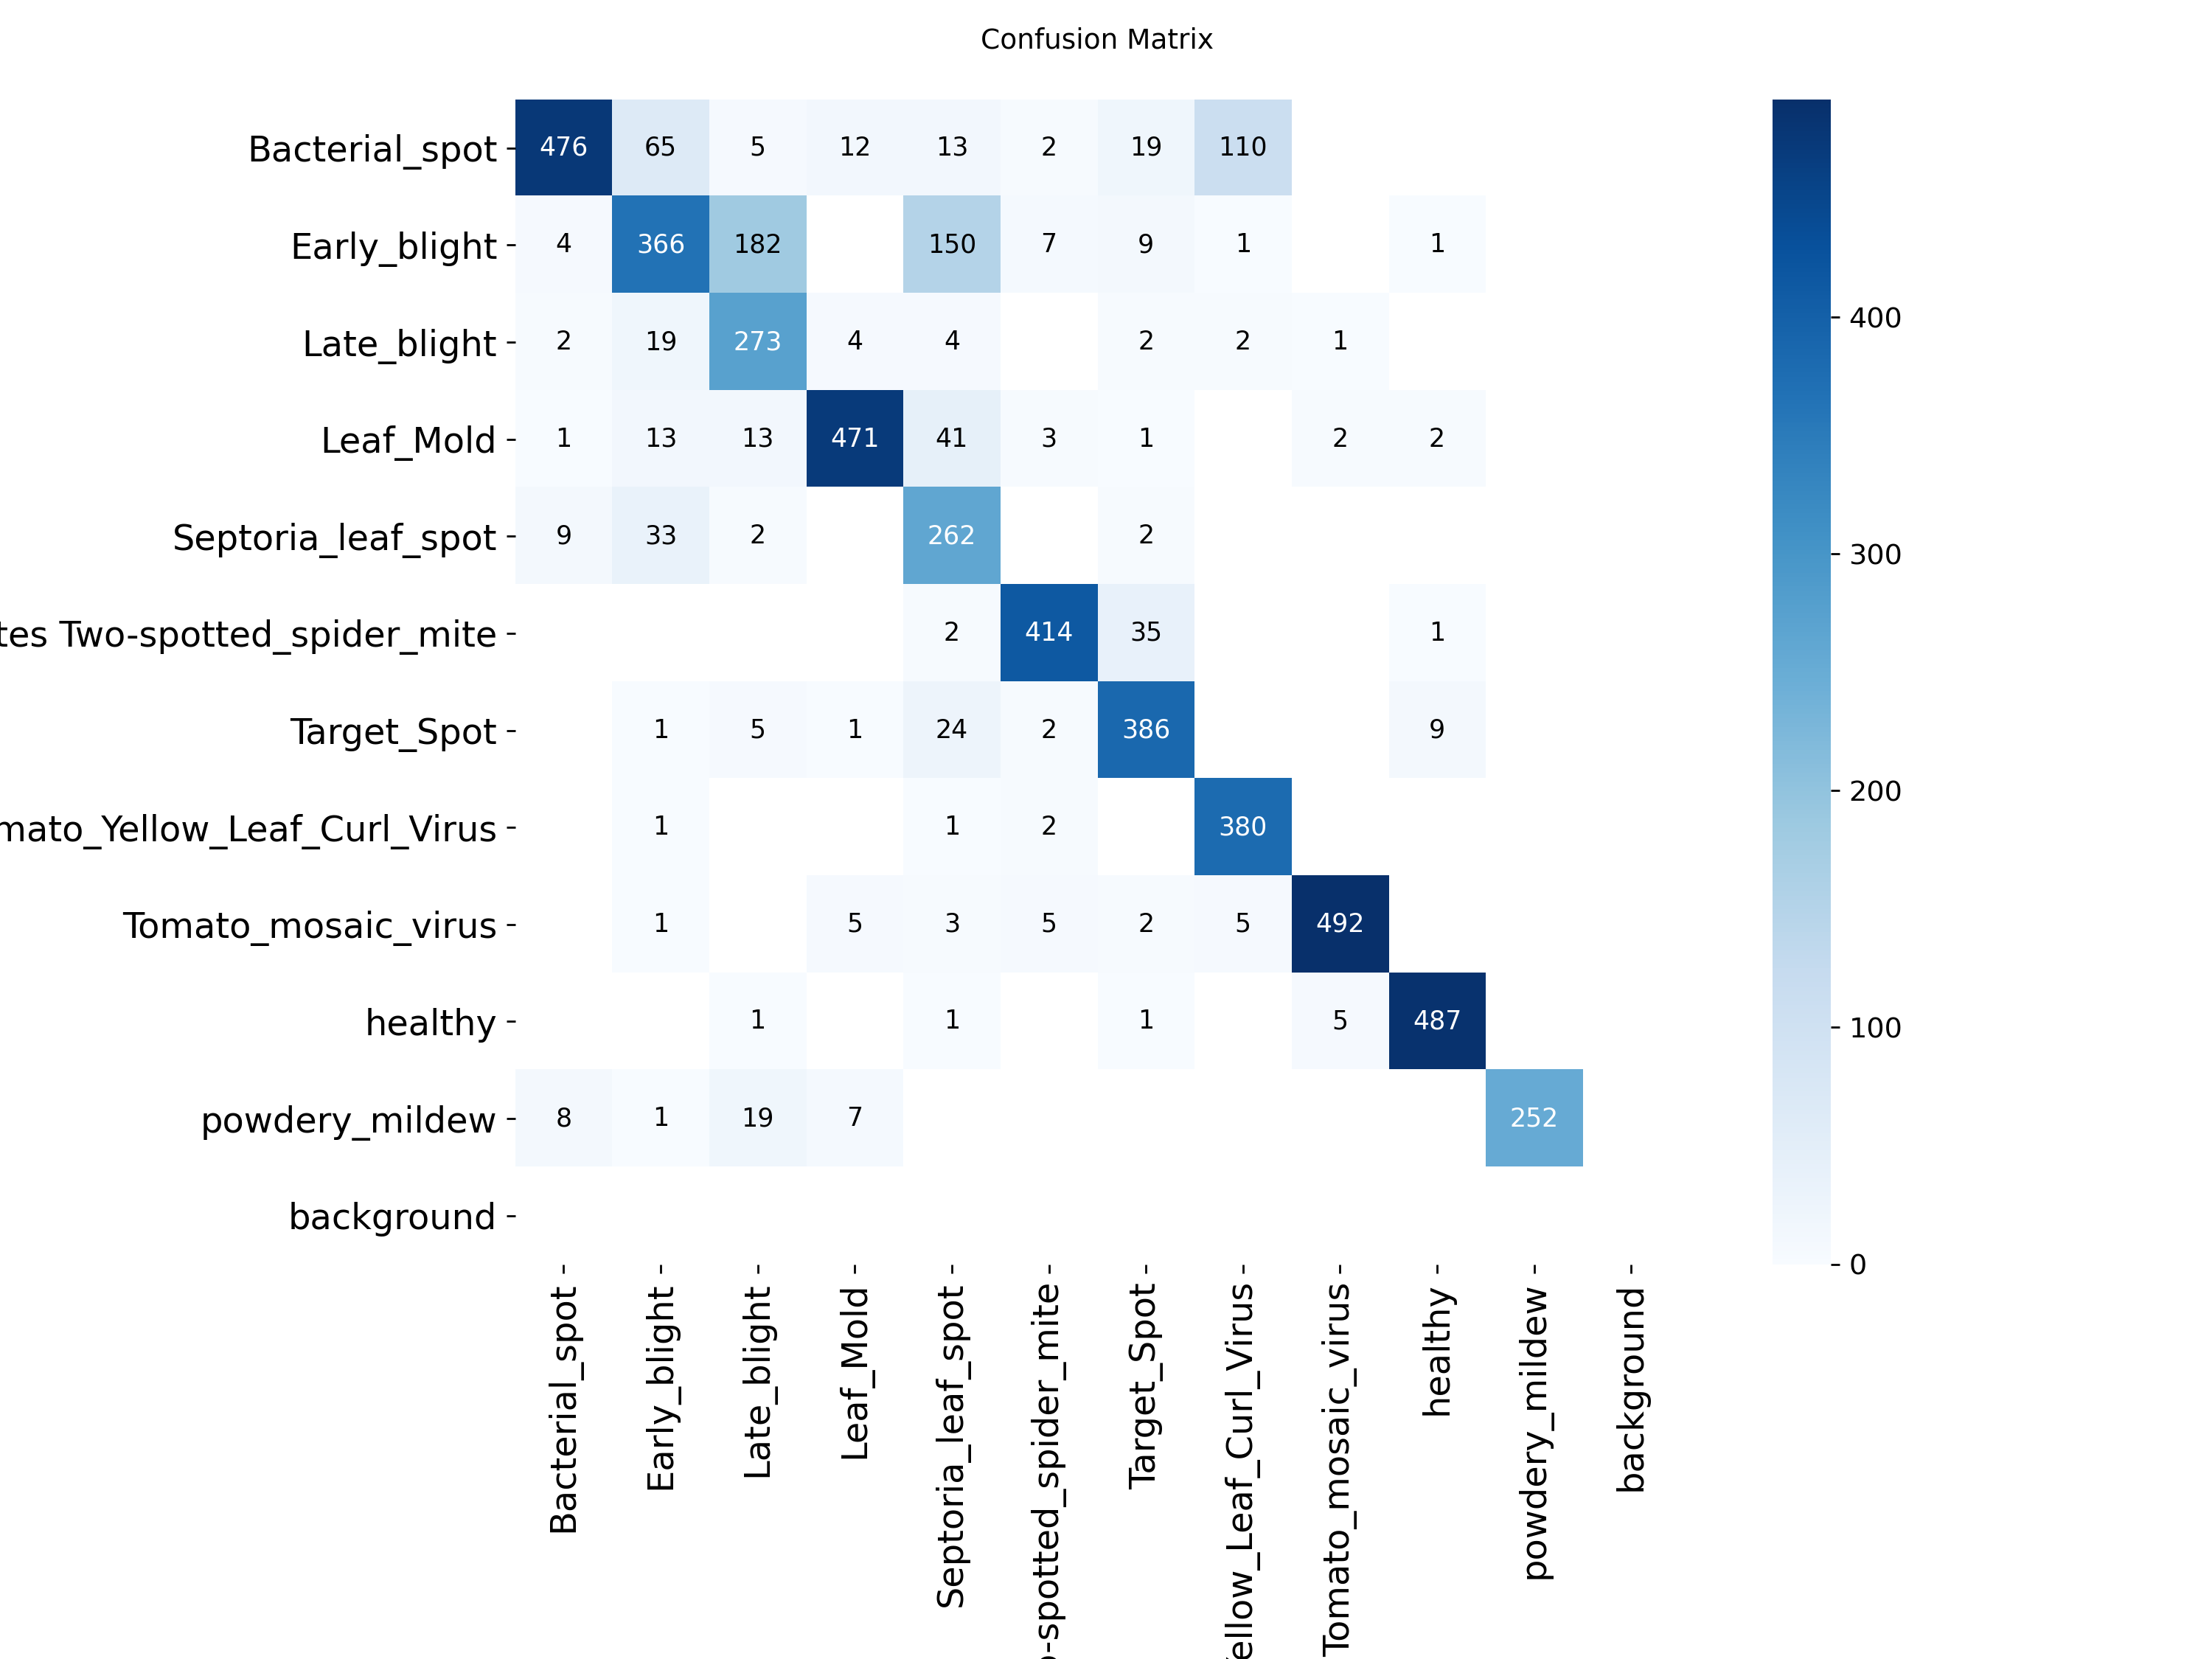

In [5]:
# Bloco 10 – Matriz de confusão (classificação)
# !pip install ultralytics

from ultralytics import YOLO
import matplotlib.pyplot as plt

# Carregar o melhor modelo treinado
modelo = YOLO('/content/drive/MyDrive/Doutorado_PGCOMP/Disciplinas/Inteligência Artificial/Workshop II/App/models/tomate.pt')

dataset_path = '/content/drive/MyDrive/Doutorado_PGCOMP/Disciplinas/Inteligência Artificial/Workshop II/App/dataset'

# Executar a validação com geração da matriz de confusão
results = modelo.val(
    data=dataset_path,
    plots=True,          # gera a matriz de confusão automaticamente
    save_json=True,      # salva métricas em JSON (opcional)
    save_dir='meus_treinos/modelo_tomate_v1'
)

# O YOLO já salva a figura da matriz de confusão no diretório de saída
# Vamos localizá-la e exibi-la no notebook
import os
from IPython.display import Image

caminho_matriz = os.path.join('meus_treinos', 'modelo_tomate_v1', 'confusion_matrix.png')
if os.path.exists(caminho_matriz):
    print("Matriz de confusão gerada e salva em:", caminho_matriz)
    display(Image(filename=caminho_matriz))
else:
    print("A matriz de confusão não foi encontrada. Verifique o diretório de saída.")